# asses the history of runs


In [5]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


## Test of disc density plotting

In [ ]:
import sys
import os
import argparse
from astropy.io import fits
import numpy as np
import scipy
import glob
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#function to plot 2D disk structure profiles
#note that 'az_disk' now stands for the azimuthal cut considered in the disk
#not the azimuthal angle under which the system is viewed (like for SED and image plotting)
def plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=False):
    #make folder to store images if needed
    if save_plots==True and os.path.exists(main_dir+sub_dir+'/figures')==False:
        os.system("mkdir "+main_dir+sub_dir+'/figures')

    #open the required grid structure file
    hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
    grid_struct=hdul[0].data
    #note we don't check for dimensionality because it's always 4D for this file
    #extract cylindrical radius and height above midplane of computation grid cell
    r = grid_struct[0, az_disk, :, :]
    z = grid_struct[1, az_disk, :, :]

    #open the required temperature, dust and gas mass density fits files and plot them
    paths=['data_th/Temperature.fits.gz', 'data_disk/dust_mass_density.fits.gz', 'data_disk/gas_density.fits.gz']
    fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
    for i, path in enumerate(paths):
        hdul=fits.open(main_dir+sub_dir+path)
        quantity_struct=hdul[0].data
        #see if we're dealing with different azimuthal zones by checking dimesnionality
        #of file & select data out of hdu accordingly
        if quantity_struct.ndim > 2:
            quantity = quantity_struct[az_disk, :, :]
        else:
            quantity = quantity_struct[:, :]

        #plotting
        cmesh = ax[i].pcolormesh(r, z, quantity, cmap='viridis', norm=LogNorm())
        cb = plt.colorbar(cmesh, ax=ax[i])
        if path == 'data_th/Temperature.fits.gz':
            cb.set_label(r'$T \, \mathrm{[K]}$')
        elif path == 'data_disk/dust_mass_density.fits.gz':
            cb.set_label(r'$\rho_{dust} \, \mathrm{[g \, cm^{-3}]}$')
        elif path == 'data_disk/gas_density.fits.gz':
            cb.set_label(r'$\rho_{gas} \, \mathrm{[g \, cm^{-3}]}$')
        ax[i].set_xlabel(r'$r \, \mathrm{[AU]}$')
        #ax[i].set_yscale('log')

        ax[i].set_ylabel(r'$z \, \mathrm{[AU]}$')
        ax[i].set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    if save_plots==True:
        fig.savefig(main_dir+sub_dir+'figures/disk_structure2D'+'_az_zone'+str(az_disk)+'.png', dpi= 100, bbox_inches='tight')


In [15]:
main_dir="/fred/oz061/kandrych/smac/20260805_edge_no_puffed_narow2_budget1_teperedp1p2_1000_no_subl/trials/trial_seed215870042_budget1.10_20260805-220730_001/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=False)


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x1527c5a10ae0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 900x1500 with 4 Axes>

In [16]:

def plot_mcfost_disk_structure(main_dir: str, sub_dir: str,  az_disk=0) -> None:

    """
    Plot the disk structure from an MCFOST parameter file.

    Parameters
    ----------
    main_dir : str
        Main directory where the simulation folder is located.
    sub_dir : str
        Subdirectory within the main directory where the simulation files are located.
    az_disk : int, optional
        Azimuthal zone to consider for the disk structure (default is 0).
    Returns
    -------
    None
    plots two (general and zoomed in inner rim) 2D cuts of the disk structure for temperature, dust mass density, and gas density.
    """
    simulation_dir = main_dir+sub_dir+'/'
    
    #make folder to store images if needed
    if os.path.exists(simulation_dir+"figures/")==False:
        os.system("mkdir "+simulation_dir+"figures/")


    #open the required grid structure file
    hdul=fits.open(simulation_dir+'data_disk/grid.fits.gz')
    grid_struct=hdul[0].data
    #note we don't check for dimensionality because it's always 4D for this file
    #extract cylindrical radius and height above midplane of computation grid cell
    r = grid_struct[0, az_disk, :, :]
    z = grid_struct[1, az_disk, :, :]


    paths = [
    ('data_th/Temperature.fits.gz', r'$T \, \mathrm{[K]}$'),
    ('data_disk/dust_mass_density.fits.gz', r'$\rho_{dust} \, \mathrm{[g\,cm^{-3}]}$'),
    ('data_disk/gas_density.fits.gz', r'$\rho_{gas} \, \mathrm{[g\,cm^{-3}]}$')
    ]

    quantities = []

    # Read each file only once
    for path, label in paths:
        with fits.open(simulation_dir + path) as hdul:
            q = hdul[0].data

        if q.ndim > 2:
            q = q[az_disk]
        quantities.append((q, label))




    fig, ax = plt.subplots(len(quantities), 1, figsize=(9, 5*len(quantities)))

    for i, (quantity, label) in enumerate(quantities):
        #check if the quantity has any positive finite values
        q = np.asarray(quantity)
        print(q)
        valid = np.isfinite(q) & (q > 0)
        if not np.any(valid):
            ax[i].text(
                0.5, 0.5,
                "No positive finite values to plot",
                ha="center", va="center",
                transform=ax[i].transAxes,
            )
            ax[i].set_title(label)
            continue

        vmin = np.nanmin(q[valid])
        vmax = np.nanmax(q[valid])
        print(f"Plotting 1 {label} with vmin={vmin}, vmax={vmax}")

        if vmin >= vmax:
            ax[i].text(
                0.5, 0.5,
                "Constant values; cannot use LogNorm",
                ha="center", va="center",
                transform=ax[i].transAxes,
            )
            ax[i].set_title(label)
            continue

        cmesh = ax[i].pcolormesh(
            r, z, q,
            cmap="viridis",
            norm=LogNorm(vmin=vmin, vmax=vmax),
            shading="nearest"
        )
        
        cb = plt.colorbar(cmesh, ax=ax[i])
        cb.set_label(label)

        ax[i].set_xlabel(r'$r\,[AU]$')
        ax[i].set_ylabel(r'$z\,[AU]$')
        ax[i].set_xlim(0, np.max(r))
    plt.suptitle('2D cut disk structure')
    plt.tight_layout()
    #fig.savefig(simulation_dir+'figures/disk_structure2D'+'.png', dpi= 150, bbox_inches='tight')
    plt.show()
    plt.close()
    


    fig, ax = plt.subplots(len(quantities), 1, figsize=(9, 5*len(quantities)))

    for i, (quantity, label) in enumerate(quantities):

        #q_norm = quantity / colmax[None, :]
        q = np.asarray(quantity)
        vmin = np.nanmin(q[(r < 100) & (z < 100) & np.isfinite(q) & (q > 0)])
        vmax = np.nanmax(q[(r < 100) & (z < 100) & np.isfinite(q) & (q > 0)])
        print(f"Plotting {label} with vmin={vmin}, vmax={vmax}")
        cmesh = ax[i].pcolormesh(r, z, q,
                                cmap='viridis',shading="nearest", vmin=vmin, vmax=vmax)

        cb = plt.colorbar(cmesh, ax=ax[i])
        cb.set_label(label)

        ax[i].set_xlabel(r'$r\,[AU]$')
        ax[i].set_ylabel(r'$z\,[AU]$')
        ax[i].set_xlim(0, 50)
        ax[i].set_ylim(0, 100)
    plt.suptitle('Zoomed inner rim 2D cut disk structure')
    #save the plot
    plt.tight_layout()
    #fig.savefig(simulation_dir+'figures/disk_structure2D_zoomed'+'.png', dpi= 150, bbox_inches='tight')
    plt.show()
    plt.close()

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
[[5.1305355e-19 5.1306446e-19 5.1308633e-19 ... 1.1401574e-17
  9.3443674e-18 7.6087034e-18]
 [4.7228787e-34 4.7232355e-34 4.7239486e-34 ... 1.0314611e-22
  6.1871099e-23 3.6268719e-23]
 [2.0792935e-35 2.0794505e-35 2.0797646e-35 ... 4.5411090e-24
  2.7239367e-24 1.5967662e-24]
 ...
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00 0.0000000e+00 ... 0.0000000e+00
  0.0000000e+00 0.0000000e+00]]
Plotting 1 $\rho_{dust} \, \mathrm{[g\,cm^{-3}]}$ with vmin=1.1953878844710748e-38, vmax=1.0682348560407673e-13
[[2.8637481e-18 2.8638091e-18 2.8639309e-18 ... 6.3641589e-17
  5.2158492e-17 4.2470262e-17]
 [2.8497501e-18 2.8498107e-18 2.8499319

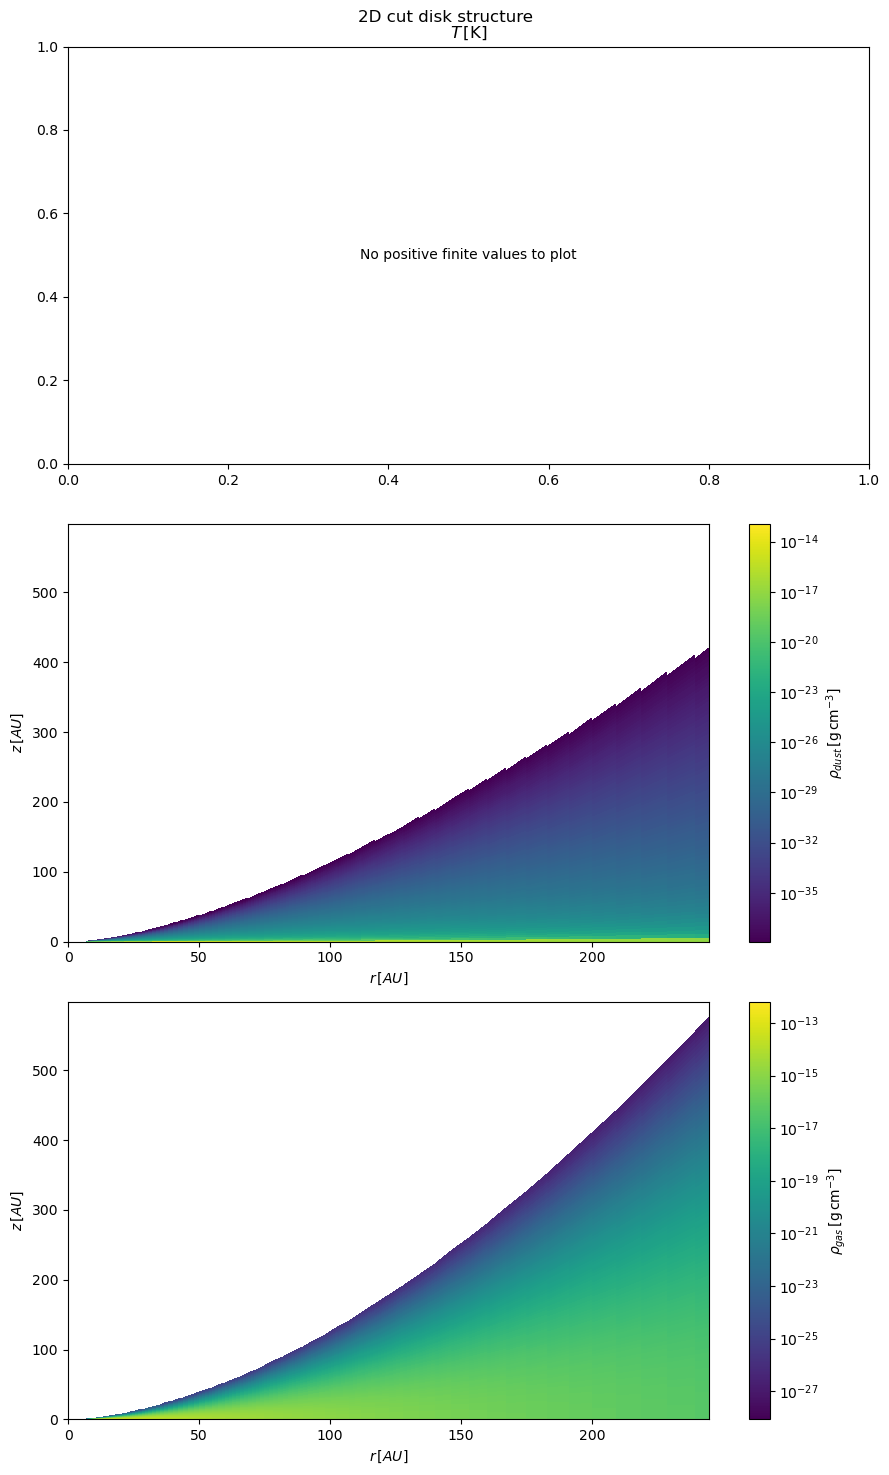

ValueError: zero-size array to reduction operation fmin which has no identity

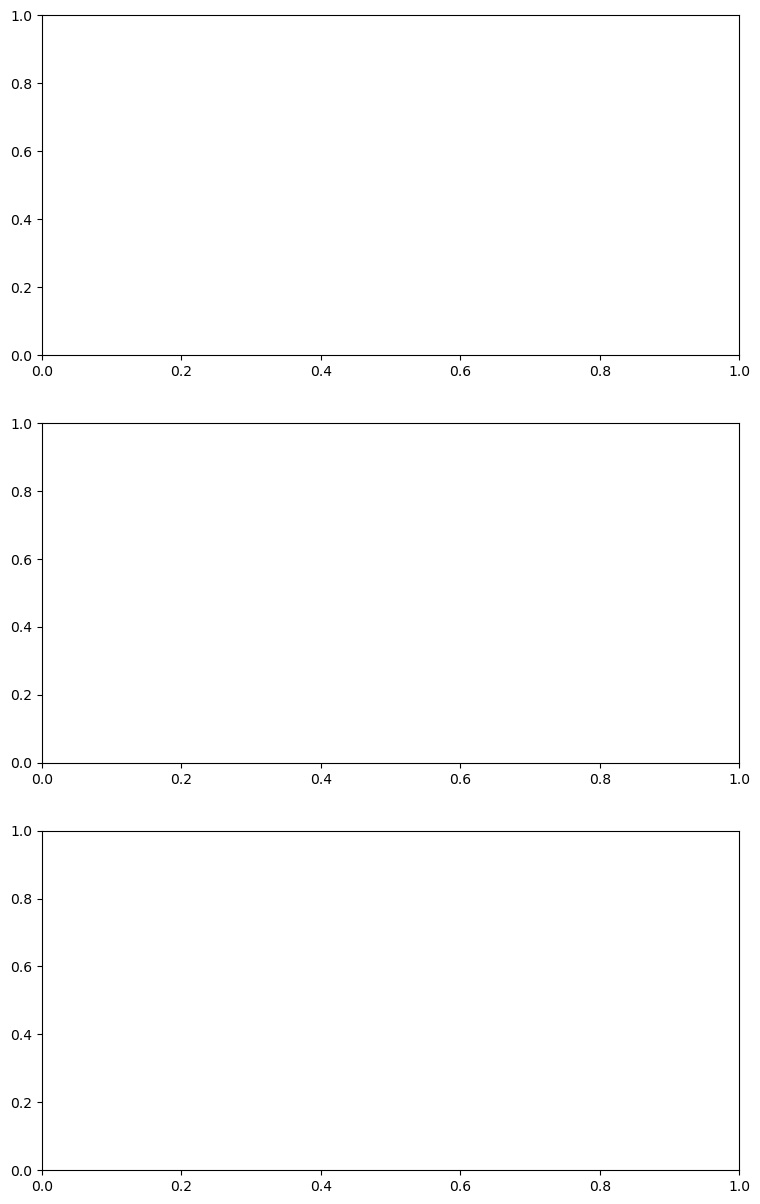

In [17]:

plot_mcfost_disk_structure(main_dir, sub_dir, az_disk=0)


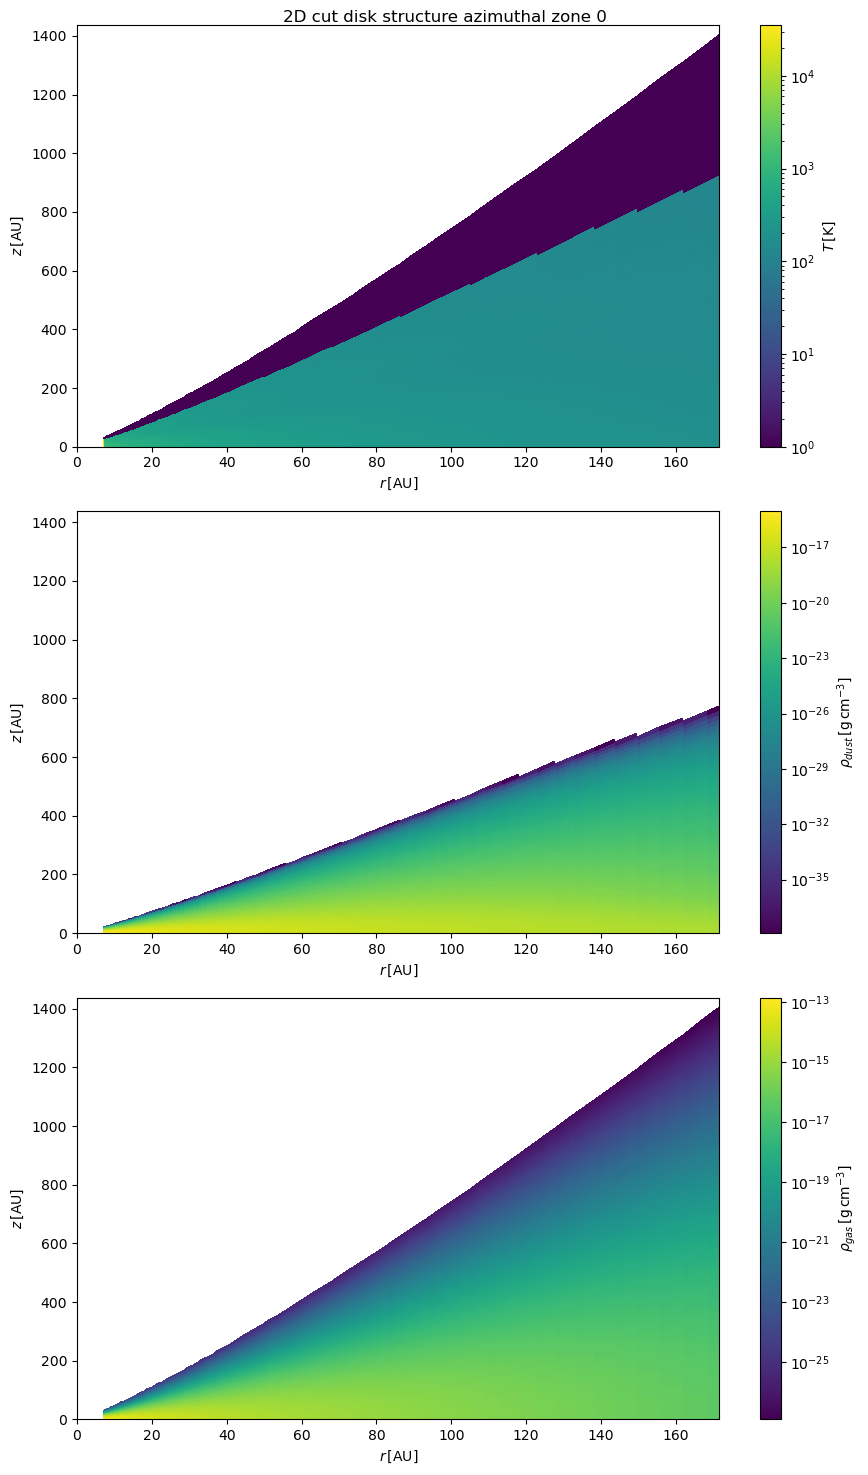

In [4]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260610_no_puffed_rim_migration_sublim/"
sub_dir=""

plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


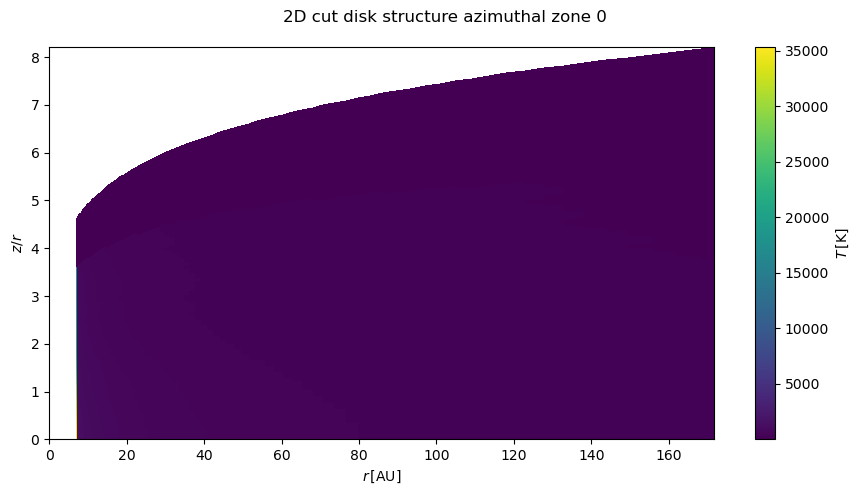

In [ ]:
az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

#open the required temperature, dust and gas mass density fits files and plot them
paths=['data_th/Temperature.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    
    #plotting
    cmesh = ax.pcolormesh(r, z/r, quantity, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax)
    
    cb.set_label(r'$T \, \mathrm{[K]}$')
    ax.set_xlabel(r'$r \, \mathrm{[AU]}$')
    ax.set_ylabel(r'$z/r$')
    ax.set_xlim(0, np.max(r))
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    plt.show()

    

In [43]:
quantity_struct.max()


35345.6

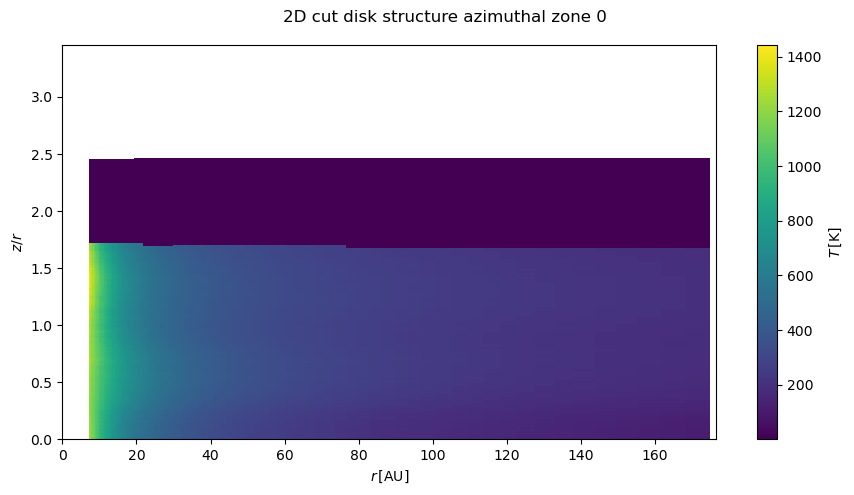

In [10]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_puffed_rim_broad_budget1/smac_results/"
sub_dir=""



az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

#open the required temperature, dust and gas mass density fits files and plot them
paths=['data_th/Temperature.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    
    #plotting
    cmesh = ax.pcolormesh(r, z/r, quantity, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax)
    
    cb.set_label(r'$T \, \mathrm{[K]}$')
    ax.set_xlabel(r'$r \, \mathrm{[AU]}$')
    ax.set_ylabel(r'$z/r$')
    ax.set_xlim(0, np.max(r)+5)
    ax.set_ylim(0, np.max(z/r)+1)
        
    plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
    #save the plot
    plt.tight_layout()
    plt.show()

    

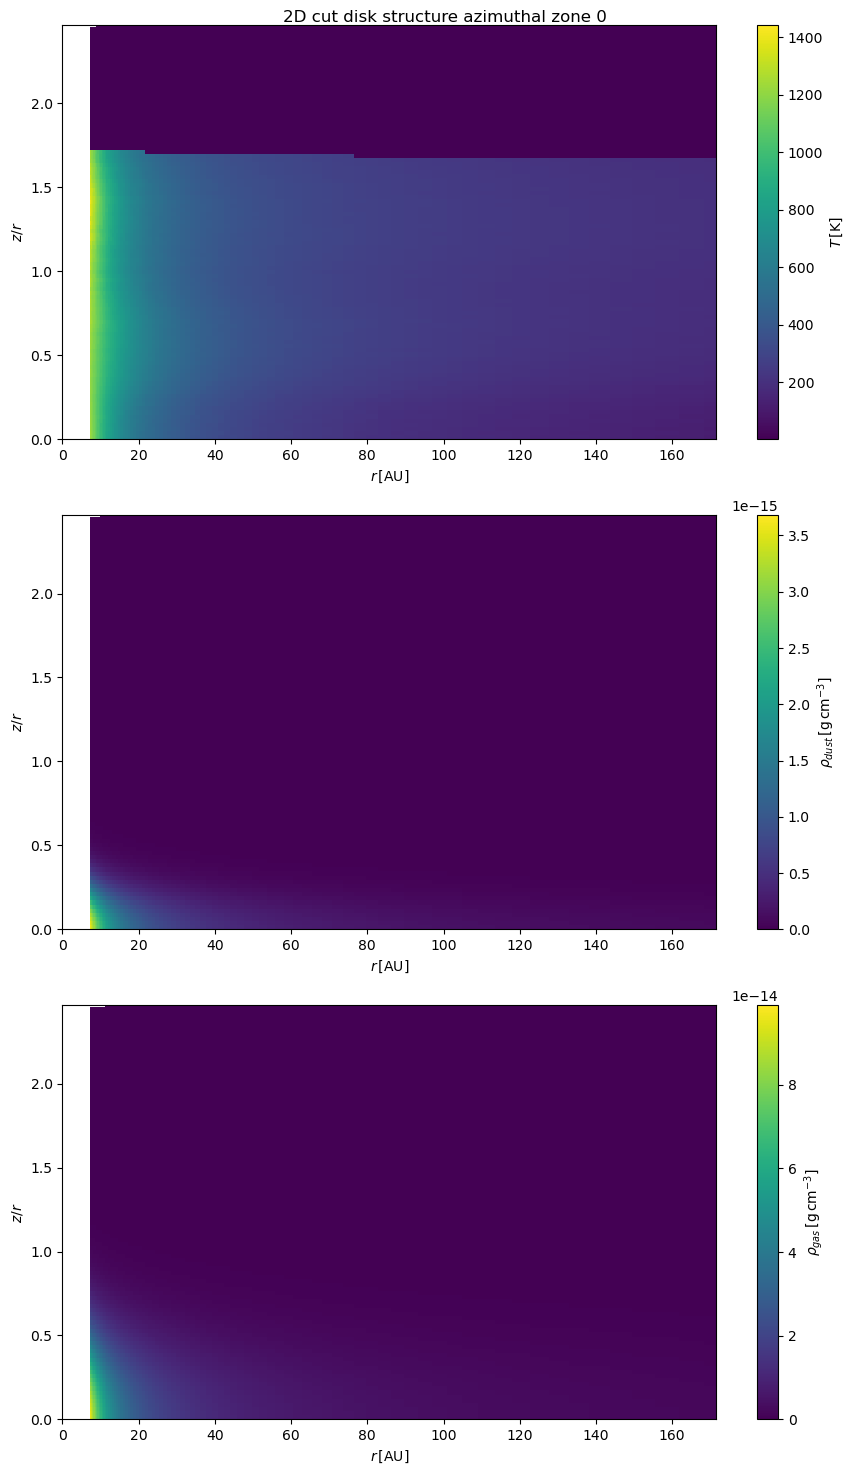

In [ ]:
main_dir="/fred/oz061/kandrych/smac/check_density/20260501_puffed_rim_broad_budget1/smac_results/"
sub_dir=""


plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


## test on structure


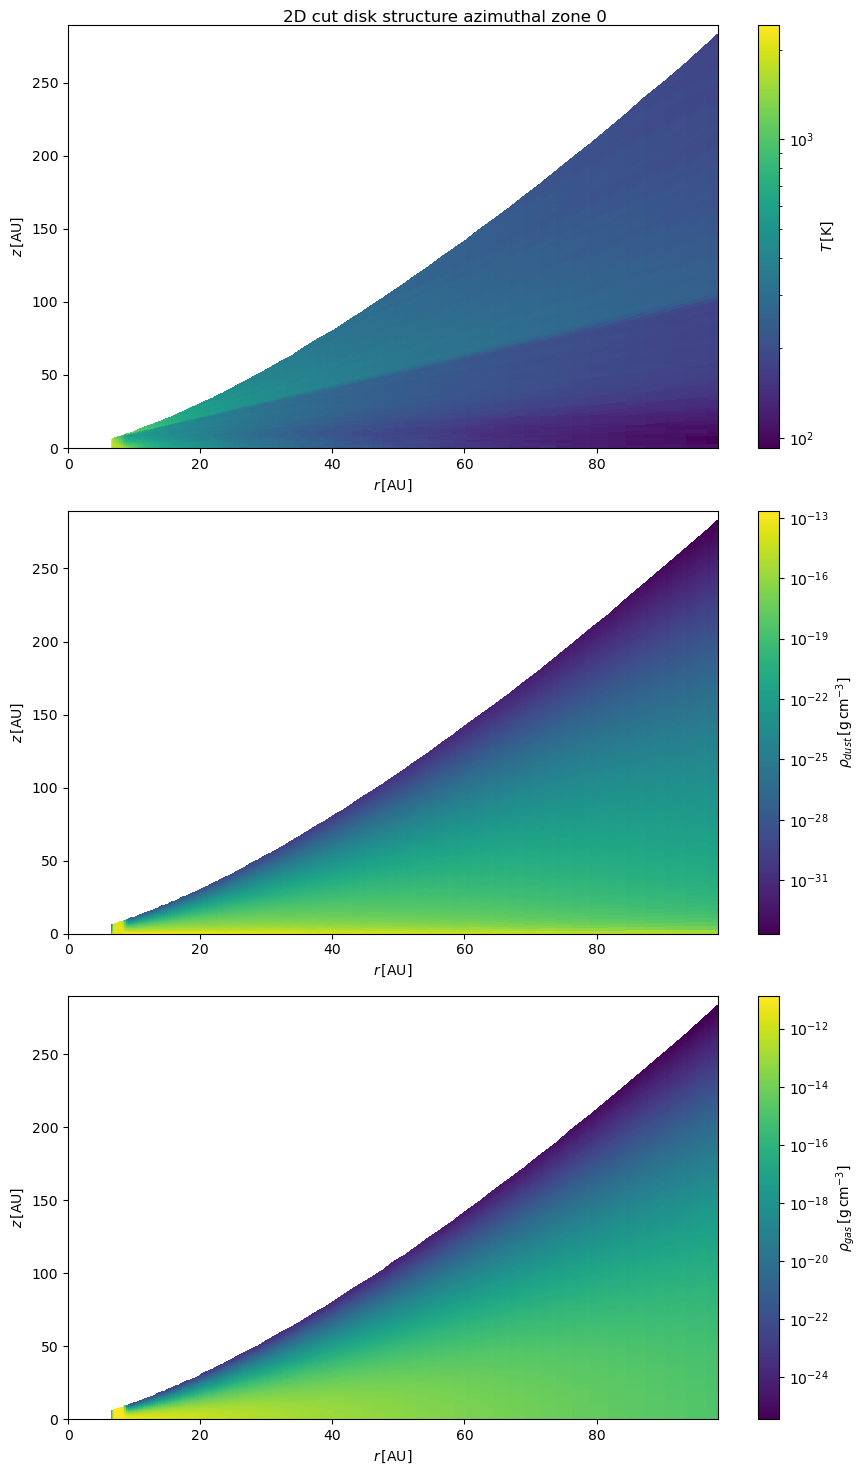

In [133]:
main_dir="/fred/oz061/kandrych/smac/check_density/inner_rim/"
sub_dir=""


plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=True)


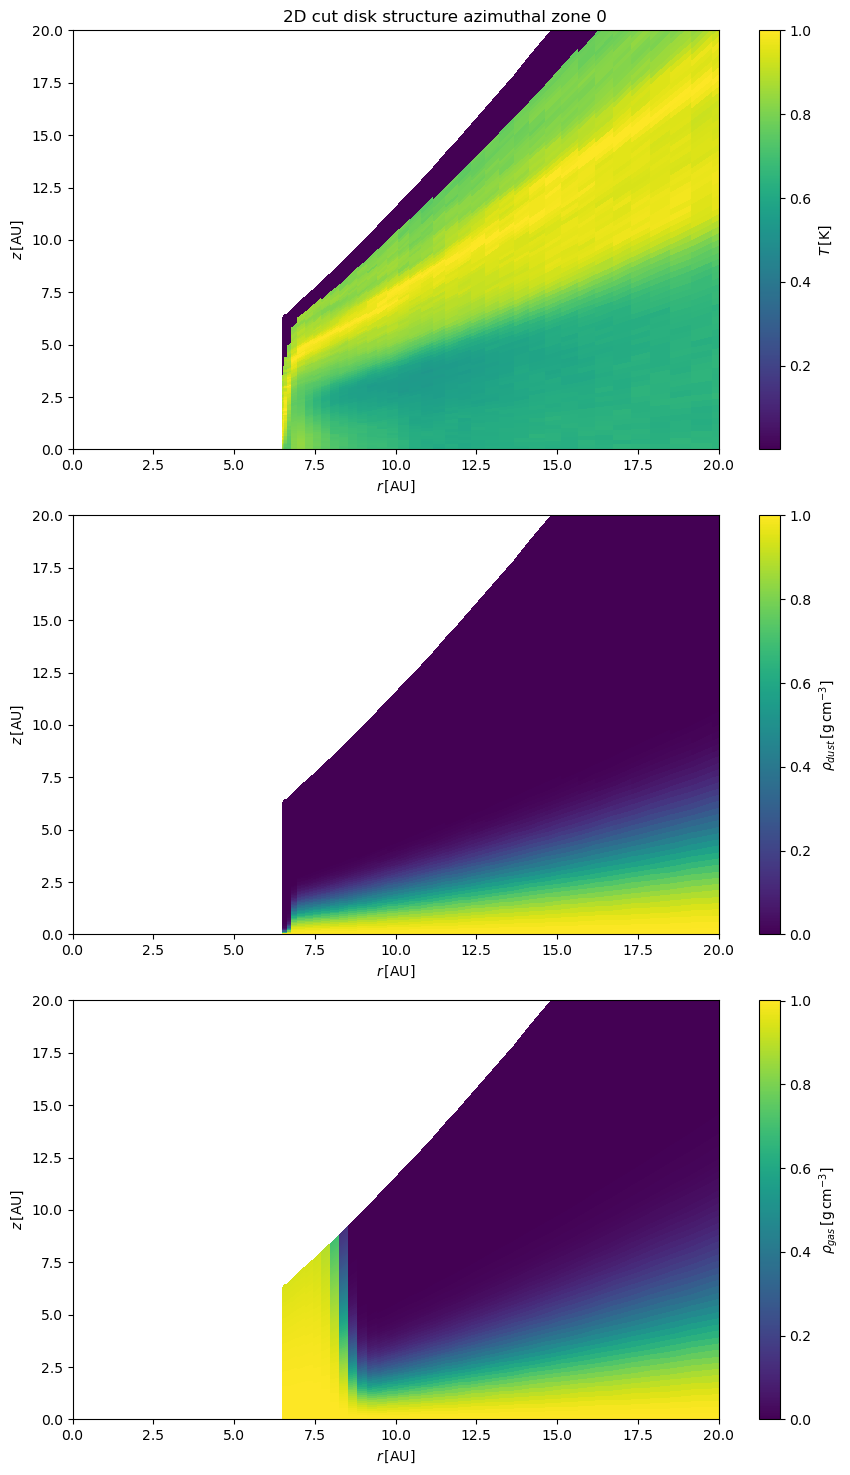

In [135]:

az_disk=0
hdul=fits.open(main_dir+sub_dir+'data_disk/grid.fits.gz')
grid_struct=hdul[0].data
#note we don't check for dimensionality because it's always 4D for this file
#extract cylindrical radius and height above midplane of computation grid cell
r = grid_struct[0, az_disk, :, :]
z = grid_struct[1, az_disk, :, :]

paths=['data_th/Temperature.fits.gz', 'data_disk/dust_mass_density.fits.gz', 'data_disk/gas_density.fits.gz']
fig, ax = plt.subplots(len(paths), 1, figsize=(9, 5*len(paths)))
for i, path in enumerate(paths):
    hdul=fits.open(main_dir+sub_dir+path)
    quantity_struct=hdul[0].data
    #see if we're dealing with different azimuthal zones by checking dimesnionality
    #of file & select data out of hdu accordingly
    if quantity_struct.ndim > 2:
        quantity = quantity_struct[az_disk, :, :]
    else:
        quantity = quantity_struct[:, :]
    q_norm = quantity / np.nanmax(quantity, axis=0)[None, :]

    #plotting
    cmesh = ax[i].pcolormesh(r, z, q_norm, cmap='viridis')
    cb = plt.colorbar(cmesh, ax=ax[i])
    if path == 'data_th/Temperature.fits.gz':
        cb.set_label(r'$T \, \mathrm{[K]}$')
    elif path == 'data_disk/dust_mass_density.fits.gz':
        cb.set_label(r'$\rho_{dust} \, \mathrm{[g \, cm^{-3}]}$')
    elif path == 'data_disk/gas_density.fits.gz':
        cb.set_label(r'$\rho_{gas} \, \mathrm{[g \, cm^{-3}]}$')
    ax[i].set_xlabel(r'$r \, \mathrm{[AU]}$')
    #ax[i].set_yscale('log')

    ax[i].set_ylabel(r'$z \, \mathrm{[AU]}$')
    ax[i].set_xlim(0, 20)
    ax[i].set_ylim(0, 20)
    
plt.suptitle('2D cut disk structure'+' azimuthal zone '+str(az_disk))
#save the plot
plt.tight_layout()
plt.show()


## Analitical density plots


/fred/oz061/kandrych/tmp/ipykernel_1043180/1063818669.py:9: RuntimeWarning: divide by zero encountered in reciprocal
  sigma_tapered=r**p1*np.exp(-(r/Rc)**(2+p2))


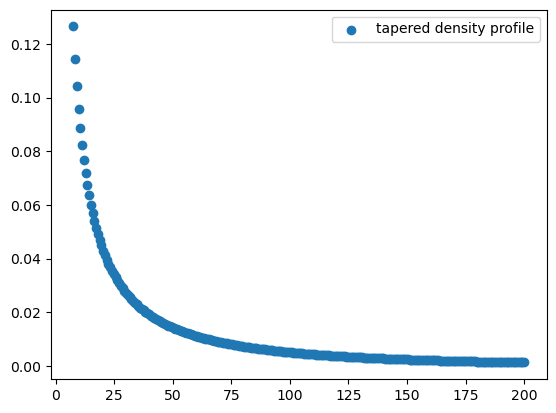

In [ ]:
#density plot for tapered edge
p1=-1
p2=p1 #here with same p1 and p2
Rc=150
rin=7
rout=200

r=np.linspace(0, rout+100, 400)
sigma_tapered=r**p1*np.exp(-(r/Rc)**(2+p2))
mask_in = r < rin
mask_out = r > rout
sigma_tapered[mask_in]=np.nan
sigma_tapered[mask_out]=np.nan
plt.scatter(r, sigma_tapered, label='tapered density profile')
plt.legend()


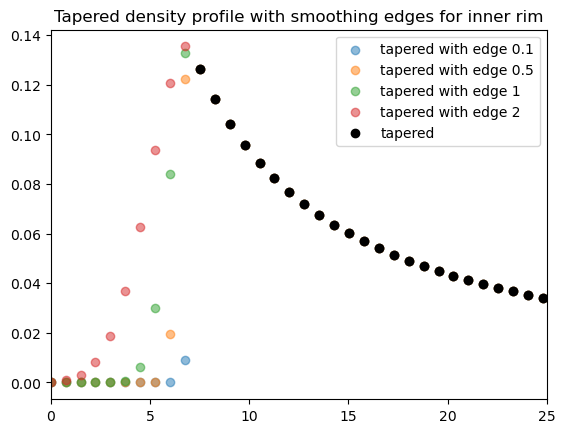

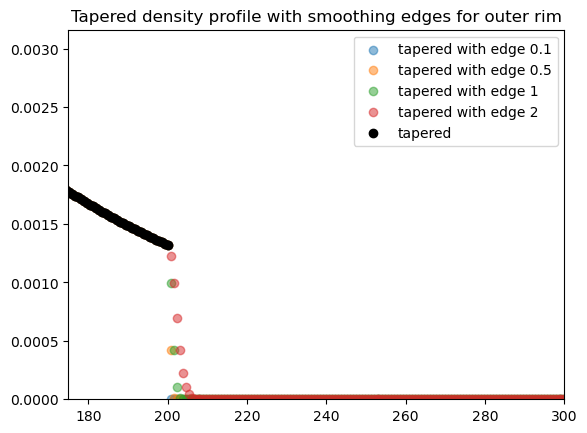

In [ ]:
#With smoothing edge for inner and outer rims

edges=[0.1,0.5,1,2]

sigma_rin = rin**p1 * np.exp(-(rin / Rc)**(2 + p2))
sigma_rout = rout**p1 * np.exp(-(rout / Rc)**(2 + p2))
sigma_tapered_edge={}
mask_in = r < rin
mask_out = r > rout
for edge in edges:
    sigma_tapered_edge[edge] = sigma_tapered.copy()
    sigma_tapered_edge[edge][mask_in] = (
        sigma_rin
        * np.exp(-0.5 * ((r[mask_in] - rin) / edge)**2)
    )

    sigma_tapered_edge[edge][mask_out] = (
        sigma_rout
        * np.exp(-0.5 * ((r[mask_out] - rout) / edge)**2)
    )

    plt.scatter(r, sigma_tapered_edge[edge], label=f'tapered with edge {edge}', alpha=0.5)
    
plt.scatter(r, sigma_tapered, label='tapered', alpha=1, color='black')
plt.title('Tapered density profile with smoothing edges for inner rim')
plt.xlim(0, 25)
plt.legend()
plt.show()
plt.close()



for edge in edges:
    plt.scatter(r, sigma_tapered_edge[edge], label=f'tapered with edge {edge}', alpha=0.5)
plt.scatter(r, sigma_tapered, label='tapered', alpha=1, color='black')
plt.title('Tapered density profile with smoothing edges for outer rim')
plt.xlim(175, 300)
plt.ylim(0, sigma_tapered[175])
plt.legend()
plt.show()
plt.close()




## Analitical scale height profile

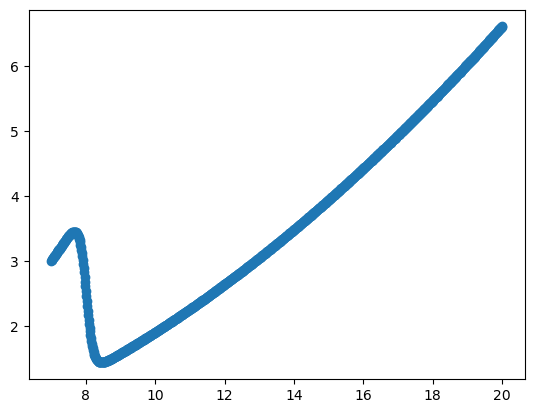

In [ ]:
##puffed inner rim scale height profile

h0=1
r0=7
hrimh0=3
rrim=8
delta_r=0.1
flaring_factor=1.8

r=np.linspace(7, 20, 1000)

h0r=h0*(r/r0)**flaring_factor

h=h0r*(1+(hrimh0 -1)/(np.exp((r-rrim)/delta_r)+1))

plt.scatter(r, h)
#plt.yscale('log')

In [3]:
from matplotlib.colors import LogNorm

def plot_mcfost_disk_structure(main_dir: str, sub_dir: str,  az_disk=0) -> None:

    """
    Plot the disk structure from an MCFOST parameter file.

    Parameters
    ----------
    main_dir : str
        Main directory where the simulation folder is located.
    sub_dir : str
        Subdirectory within the main directory where the simulation files are located.
    az_disk : int, optional
        Azimuthal zone to consider for the disk structure (default is 0).
    Returns
    -------
    None
    plots two (general and zoomed in inner rim) 2D cuts of the disk structure for temperature, dust mass density, and gas density.
    """
    simulation_dir = main_dir+sub_dir+'/'
    
    #make folder to store images if needed
    if os.path.exists(simulation_dir+"figures/")==False:
        os.system("mkdir "+simulation_dir+"figures/")


    #open the required grid structure file
    hdul=fits.open(simulation_dir+'data_disk/grid.fits.gz')
    grid_struct=hdul[0].data
    #note we don't check for dimensionality because it's always 4D for this file
    #extract cylindrical radius and height above midplane of computation grid cell
    r = grid_struct[0, az_disk, :, :]
    z = grid_struct[1, az_disk, :, :]


    paths = [
    ('data_th/Temperature.fits.gz', r'$T \, \mathrm{[K]}$'),
    ('data_disk/dust_mass_density.fits.gz', r'$\rho_{dust} \, \mathrm{[g\,cm^{-3}]}$'),
    ('data_disk/gas_density.fits.gz', r'$\rho_{gas} \, \mathrm{[g\,cm^{-3}]}$')
    ]

    quantities = []

    # Read each file only once
    for path, label in paths:
        with fits.open(simulation_dir + path) as hdul:
            q = hdul[0].data

        if q.ndim > 2:
            q = q[az_disk]
        quantities.append((q, label))




    fig, ax = plt.subplots(len(quantities), 1, figsize=(9, 5*len(quantities)))

    for i, (quantity, label) in enumerate(quantities):
        cmesh = ax[i].pcolormesh(r, z, quantity,
                                cmap='viridis',
                                norm=LogNorm())
        cb = plt.colorbar(cmesh, ax=ax[i])
        cb.set_label(label)

        ax[i].set_xlabel(r'$r\,[AU]$')
        ax[i].set_ylabel(r'$z\,[AU]$')
        ax[i].set_xlim(0, np.max(r))
    plt.suptitle('2D cut disk structure')
    plt.tight_layout()
    plt.show()
    plt.close()
    #fig.savefig(simulation_dir+'figures/disk_structure2D'+'.png', dpi= 150, bbox_inches='tight')



    fig, ax = plt.subplots(len(quantities), 1, figsize=(9, 5*len(quantities)))

    for i, (quantity, label) in enumerate(quantities):

        colmax = np.nanmax(quantity, axis=0)
        colmax[colmax == 0] = np.nan
        q_norm = quantity / colmax[None, :]

        cmesh = ax[i].pcolormesh(r, z, q_norm,
                                cmap='viridis')

        cb = plt.colorbar(cmesh, ax=ax[i])
        cb.set_label("Normalized " + label)

        ax[i].set_xlabel(r'$r\,[AU]$')
        ax[i].set_ylabel(r'$z\,[AU]$')
        ax[i].set_xlim(0, 20)
        ax[i].set_ylim(0, 20)
    plt.suptitle('Zoomed inner rim 2D cut disk structure')
    #save the plot
    plt.tight_layout()
    plt.show()
    plt.close()
    #fig.savefig(simulation_dir+'figures/disk_structure2D_zoomed'+'.png', dpi= 150, bbox_inches='tight')




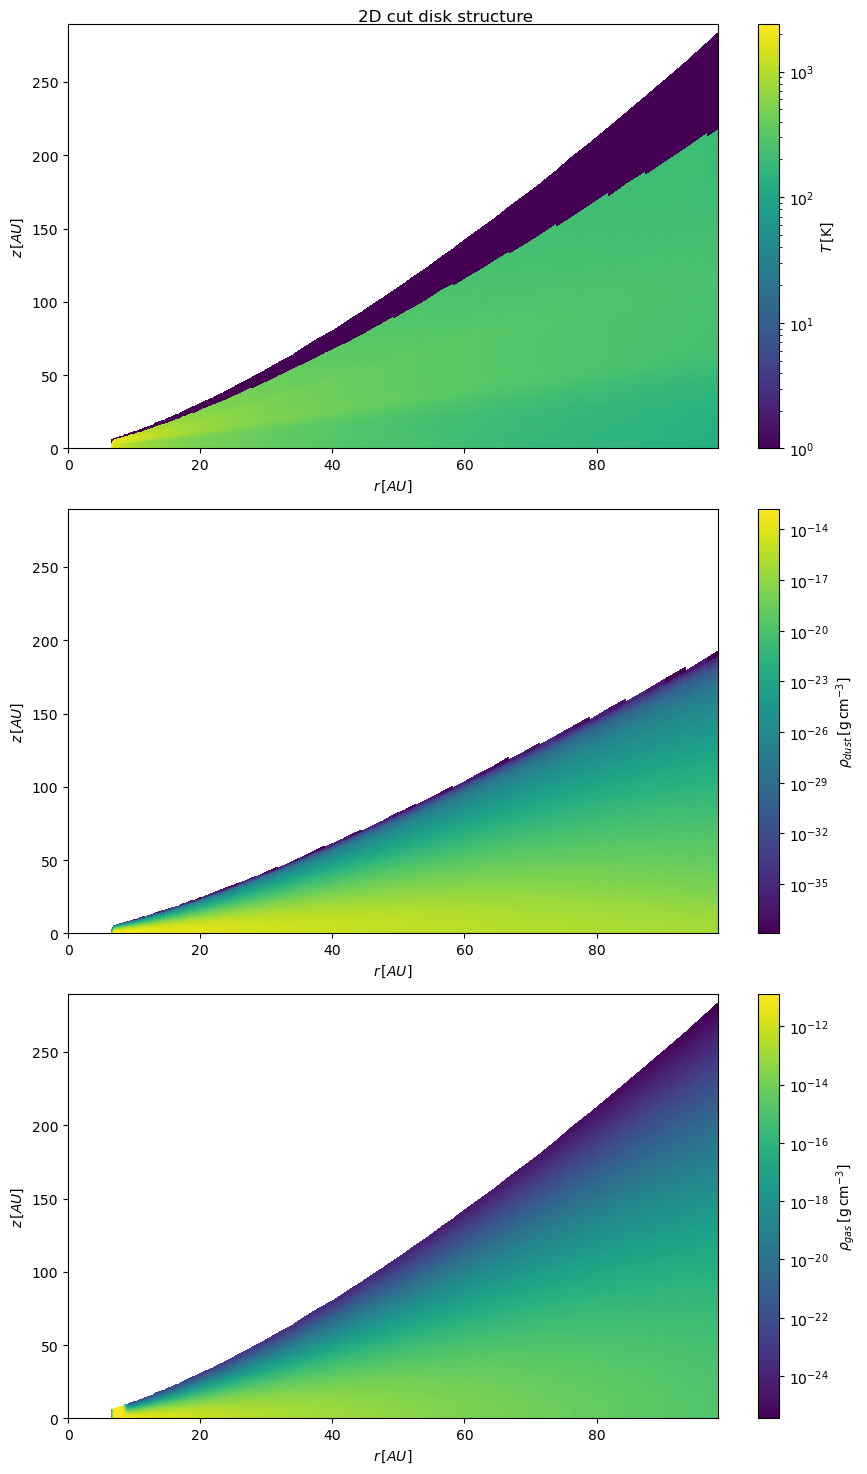

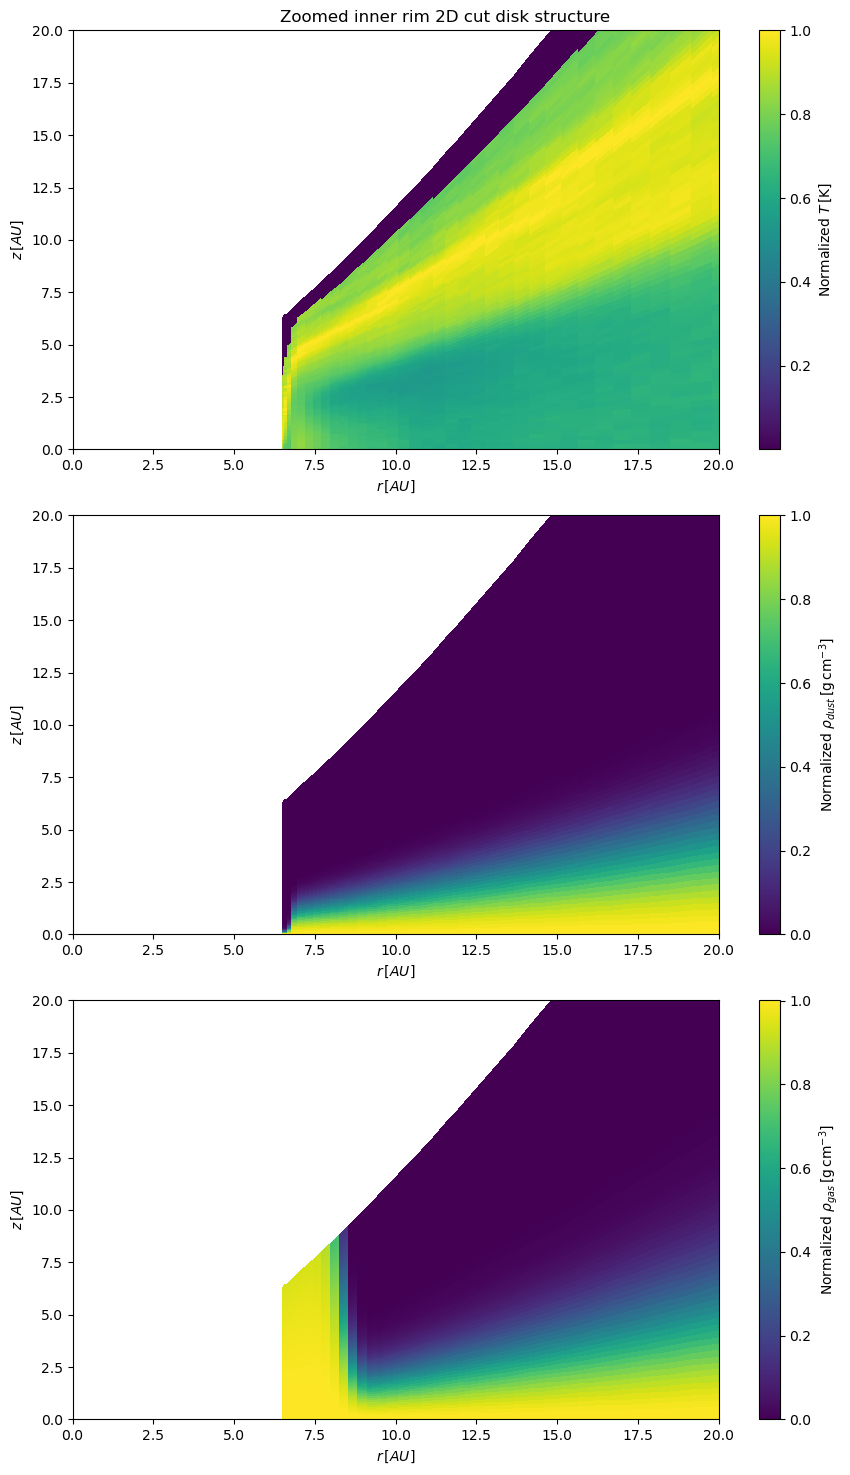

In [4]:
main_dir="/fred/oz061/kandrych/smac/check_density/inner_rim/"
sub_dir=""


plot_mcfost_disk_structure(main_dir, sub_dir, az_disk=0)

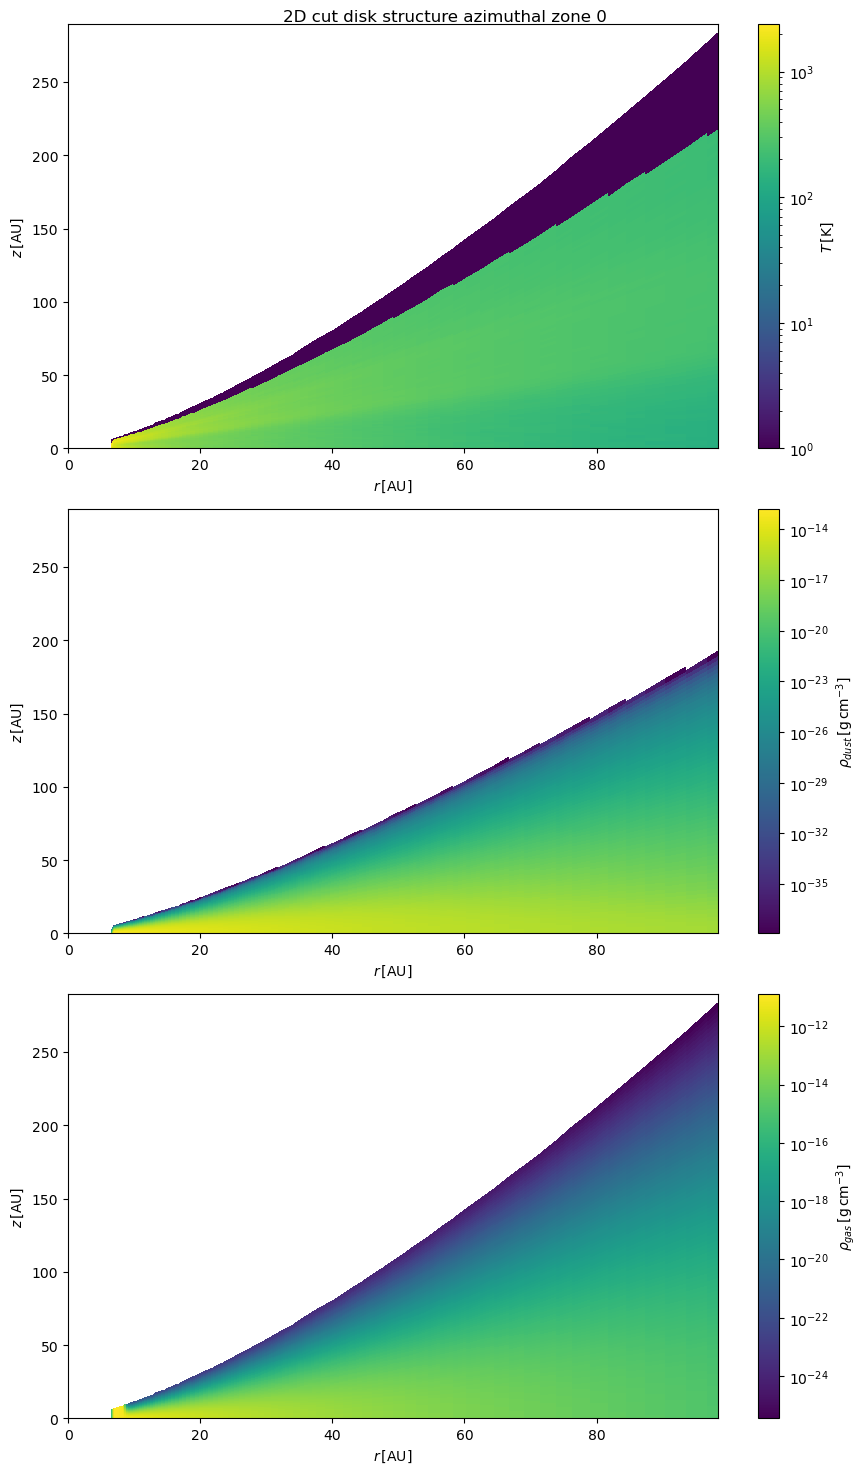

In [5]:
plot_disk_struct(main_dir, sub_dir, az_disk=0, save_plots=False)
